In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def psnr(img1, img2):

    assert img1.shape == img2.shape, "이미지 크기가 다릅니다!"

    # 이미지가 float 타입이면, 0~1 기준으로 PSNR 계산
    if img1.dtype == np.float32 or img1.dtype == np.float64:
        max_pixel = 1.0
    else:
        max_pixel = 255.0

    # MSE (Mean Squared Error)
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')  # 완전히 같으면 PSNR은 무한대

    # PSNR 계산
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

from google.colab import drive
drive.mount('/content/drive')

# 이미지 로드 및 변환 (RGB 이미지)
image = cv2.imread('/content/drive/My Drive/Colab Notebooks/lena.bmp', cv2.IMREAD_COLOR)
image_original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Image denoising
# Gaussian noise
def g_noise(image, std):
    H, W, C = image.shape
    gauss = np.random.normal(0, std, image.shape)
    noisy = image + gauss
    noisy_image = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy_image

# Impulse noise with(p) to the original image
def i_noise(image, prob):
    noisy = image.copy()
    H, W, _ = image.shape
    num_pixels = H * W
    num_noisy = int(prob * num_pixels)

    # 전체 픽셀 좌표 (1D index)
    all_coords = np.arange(num_pixels)  # 1D 배열 생성
    np.random.shuffle(all_coords)       # 인덱스 섞기

    # 나눠서 salt & pepper 좌표 뽑기
    salt_coords = all_coords[:num_noisy // 2]
    pepper_coords = all_coords[num_noisy // 2:num_noisy]

    # 1D 인덱스를 2D로 변환
    salt_y, salt_x = np.unravel_index(salt_coords, (H, W))
    pepper_y, pepper_x = np.unravel_index(pepper_coords, (H, W))

    # 적용
    noisy[salt_y, salt_x, :] = 255
    noisy[pepper_y, pepper_x, :] = 0

    return noisy

In [ ]:
# image denoising

########## 2D Median filtered with noise detection for Impulse noise
def median_filter(image, size):
    H, W, C = image.shape
    pad = size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    filtered = np.copy(image)  # 원본 유지하면서 필요한 부분만 수정

    for y in range(H):
        for x in range(W):
            for c in range(C):
                # Impulse noise (0 또는 255)일 경우만 필터 적용 조건
                pixel_val = image[y, x, c]
                if pixel_val == 0 or pixel_val == 255:
                    # 여기는 필터링
                    window = padded[y:y+size, x:x+size, c]
                    filtered[y, x, c] = np.median(window)

    return filtered.astype(np.uint8)

############### averaging filter
def averaging_filter(image, size):

    # 커널 생성
    kernel = np.ones((size, size)) / (size * size)
    pad_size = size // 2
    padded = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='reflect')

    output = np.zeros_like(image)     # 출력 이미지 생성

    for c in range(image.shape[2]):
        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                region = padded[i:i+size, j:j+size, c]
                output[i, j, c] = np.sum(region * kernel)

    return output

########### Gaussian denoising filter
def gaussian_filter(image, size, std):
    pad = size // 2
    H, W, C = image.shape

    # 가우시안 커널 생성
    k_x = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(k_x, k_x)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * std**2))
    kernel = kernel / np.sum(kernel)

    # 이미지 패딩
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')

    # 커널 적용
    filtered = np.zeros_like(image, dtype=np.float64)
    for y in range(H):
        for x in range(W):
            for c in range(C):
                region = padded[y:y+size, x:x+size, c]
                filtered[y, x, c] = np.sum(region * kernel)

    return np.clip(filtered, 0, 255).astype(np.uint8)


############# bilateral filter

def bilateral_filter(image,size, sigma_color, sigma_space):

    """
    - diameter: 필터 윈도우 크기
    - sigma_color: 색상 가우시안 sigma
    - sigma_space: 거리 가우시안 sigma
    """

    img = image.astype(np.float32)
    H, W, C = img.shape
    pad = size // 2
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    output = np.zeros_like(img)

    # 거리 가우시안 커널
    ax = np.arange(-pad, pad + 1)
    # 필터 범위 좌표 격자
    xx, yy = np.meshgrid(ax, ax)
    # 거리 기반 가우시안 필터
    spatial_kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma_space**2))

    for y in range(H):
        for x in range(W):
            for c in range(C):
                center_val = padded[y+pad, x+pad, c]
                region = padded[y:y+size, x:x+size, c]

                # 색상 차이 가우시안, 색이 비슷하면 높은 값 다르면 낮은 값
                color_diff = region - center_val
                color_kernel = np.exp(-(color_diff ** 2) / (2 * sigma_color ** 2))

                # 최종 필터는 공간+색상 곱
                bilateral_weights = spatial_kernel * color_kernel
                bilateral_weights /= np.sum(bilateral_weights)

                output[y, x, c] = np.sum(region * bilateral_weights)

    return np.clip(output, 0, 255).astype(np.uint8)

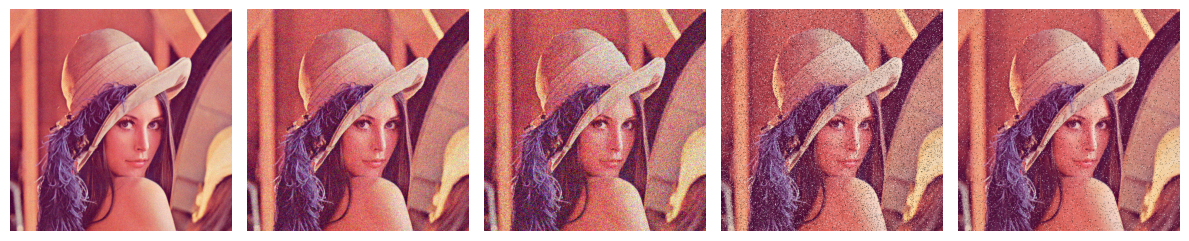

In [ ]:
g10 = g_noise(image_original,10)
g30 = g_noise(image_original,30)
g50 = g_noise(image_original,50)
i01 = i_noise(image_original,0.1)
i005= i_noise(image_original,0.05)

plt.figure(figsize=(12, 4))
plt.subplot(1,5,1)
plt.imshow(g10)
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(g30)
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(g50)
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(i01)
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(i005)
plt.axis('off')

plt.tight_layout()
plt.show()


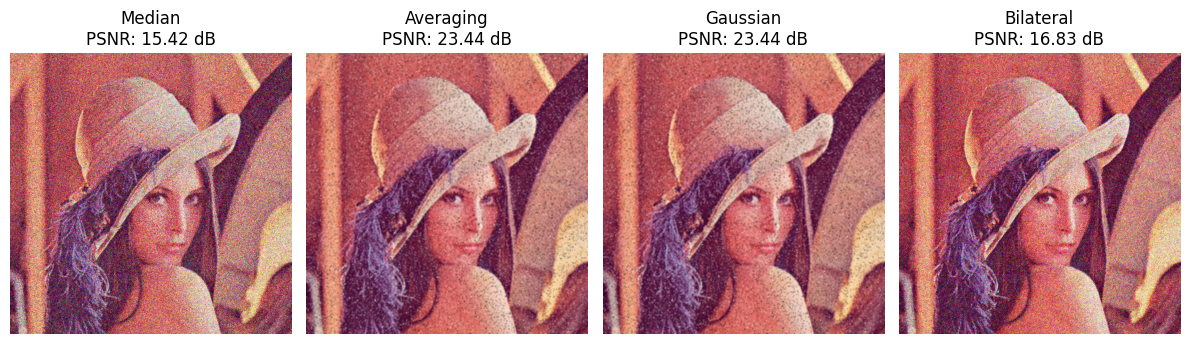

In [ ]:
plt.figure(figsize=(12, 4))

# Median Filter
plt.subplot(1, 4, 1)
median_filtered = median_filter(g50, 5)
psnr_median = psnr(image_original, median_filtered)
plt.imshow(median_filtered)
plt.title(f"Median\nPSNR: {psnr_median:.2f} dB")
plt.axis('off')

# Averaging Filter
plt.subplot(1, 4, 2)
averaging_filtered = averaging_filter(i01, 3)
psnr_averaging = psnr(image_original, averaging_filtered)
plt.imshow(averaging_filtered)
plt.title(f"Averaging\nPSNR: {psnr_averaging:.2f} dB")
plt.axis('off')

# Gaussian Filter
plt.subplot(1, 4, 3)
gaussian_filtered =  gaussian_filter(i01, 3,15)
psnr_gaussian = psnr(image_original, gaussian_filtered)
plt.imshow(gaussian_filtered)
plt.title(f"Gaussian\nPSNR: {psnr_gaussian:.2f} dB")
plt.axis('off')

# Bilateral Filter
plt.subplot(1, 4, 4)
bilateral_filtered = bilateral_filter(g50, 5, 30, 15)
psnr_bilateral = psnr(image_original, bilateral_filtered)
plt.imshow(bilateral_filtered)
plt.title(f"Bilateral\nPSNR: {psnr_bilateral:.2f} dB")
plt.axis('off')

plt.tight_layout()
plt.show()